# Annotators como capas

Capas que nos permiten dibujar encima de una imagen, existen distintos tipos, el ultimo annotator importa ya que es el que queda visualmente encima

In [1]:
import supervision as sv
from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt

model = YOLO("../../assets/curso/models/yolov8n.pt")

image = cv2.imread("../../assets/curso/images/bus.jpg")

results = model(image)[0]
detections = sv.Detections.from_ultralytics(results)

labels = [
    f"{results.names[c]} {conf:.0%}"
    for c, conf in zip(detections.class_id, detections.confidence)
]

print(f"Pipeline listo: {len(detections)} detecciones")


0: 640x480 4 persons, 1 bus, 1 stop sign, 973.9ms
Speed: 40.6ms preprocess, 973.9ms inference, 64.1ms postprocess per image at shape (1, 3, 640, 480)
Pipeline listo: 6 detecciones


Identificamos estadisticas de confianza de los objetos

In [2]:
# Inspección rápida del estado intermedio del pipeline
print(f"Objetos detectados: {len(detections)}")
print(f"Clases únicas:      {sorted(set(detections.class_id))}")
print(f"Confianza mínima:   {detections.confidence.min():.1%}")
print(f"Confianza máxima:   {detections.confidence.max():.1%}")

# Las primeras etiquetas que se usarán en los annotators de texto
# Imprimirlas ayuda a anticipar cómo se verán en la imagen
print(f"\nPrimeras 3 etiquetas: {labels[:3]}")

Objetos detectados: 6
Clases únicas:      [np.int64(0), np.int64(5), np.int64(11)]
Confianza mínima:   25.5%
Confianza máxima:   87.3%

Primeras 3 etiquetas: ['bus 87%', 'person 87%', 'person 85%']


## Catálogo de annotators

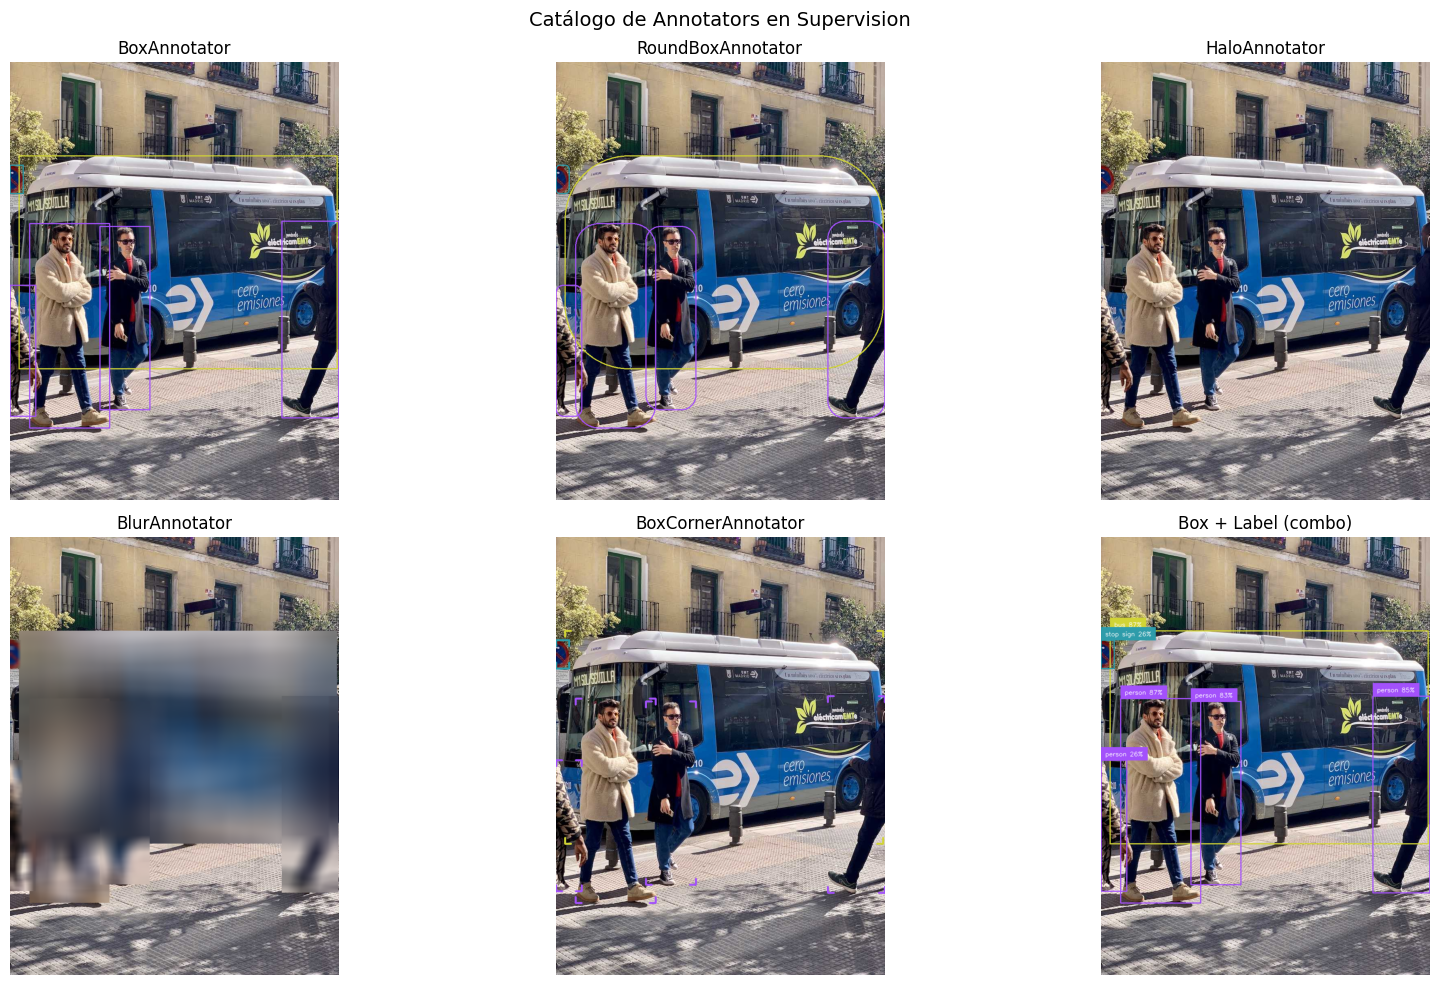

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Cada annotator se instancia una sola vez y se reutiliza
# Crear el annotator dentro de un bucle reinicializa su estado en cada iteración
configs = [
    ("BoxAnnotator",       sv.BoxAnnotator()),
    ("RoundBoxAnnotator",  sv.RoundBoxAnnotator()),
    ("HaloAnnotator",      sv.HaloAnnotator()),
    ("BlurAnnotator",      sv.BlurAnnotator()),
    ("BoxCornerAnnotator", sv.BoxCornerAnnotator()),
    ("Box + Label (combo)", None),
]

for ax, (name, annotator) in zip(axes.flat, configs):
    if name == "Box + Label (combo)":
        # Demostración de composición: el resultado de uno es la entrada del siguiente
        scene = sv.BoxAnnotator().annotate(scene=image.copy(), detections=detections)
        scene = sv.LabelAnnotator().annotate(scene=scene, detections=detections, labels=labels)
    else:
        scene = annotator.annotate(scene=image.copy(), detections=detections)
    ax.imshow(cv2.cvtColor(scene, cv2.COLOR_BGR2RGB))
    ax.set_title(name, fontsize=12)
    ax.axis("off")

plt.suptitle("Catálogo de Annotators en Supervision", fontsize=14)
plt.tight_layout()
plt.show()

## Personalización

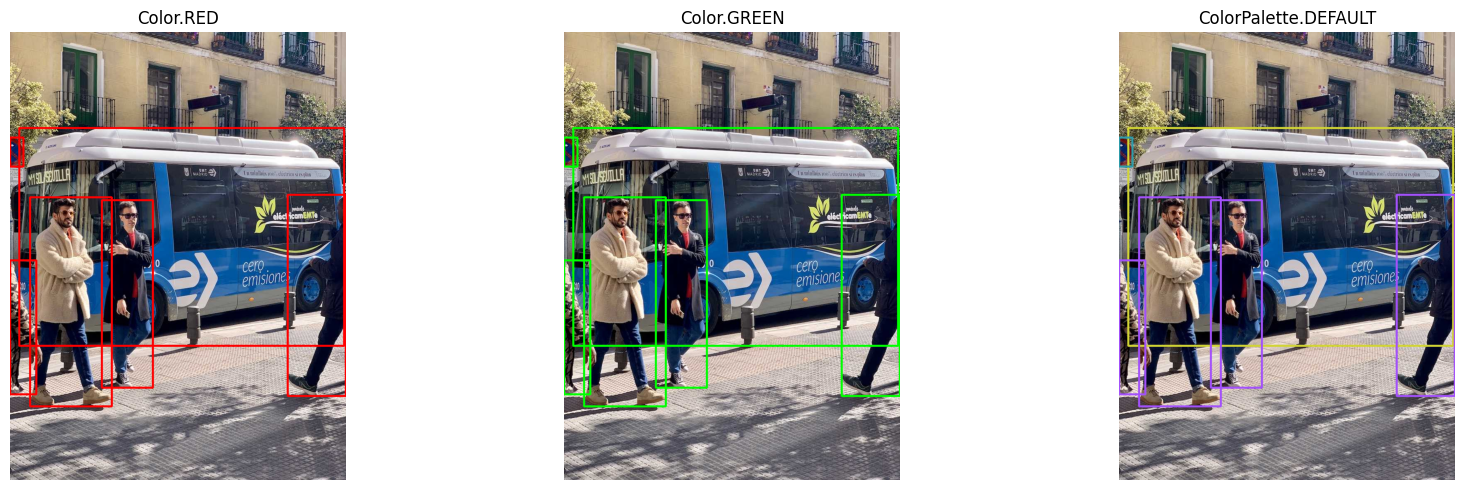

In [4]:
# sv.Color tiene colores predefinidos accesibles como atributos
anotador_rojo   = sv.BoxAnnotator(color=sv.Color.RED,   thickness=3)
anotador_verde  = sv.BoxAnnotator(color=sv.Color.GREEN, thickness=3)
# sv.ColorPalette.DEFAULT asigna automáticamente un color diferente a cada clase
# — útil cuando tienes muchas categorías y no quieres asignarlas manualmente
anotador_paleta = sv.BoxAnnotator(color=sv.ColorPalette.DEFAULT, thickness=3)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (titulo, ann) in zip(axes, [
    ("Color.RED",            anotador_rojo),
    ("Color.GREEN",          anotador_verde),
    ("ColorPalette.DEFAULT", anotador_paleta),
]):
    scene = ann.annotate(scene=image.copy(), detections=detections)
    ax.imshow(cv2.cvtColor(scene, cv2.COLOR_BGR2RGB))
    ax.set_title(titulo)
    ax.axis("off")
plt.tight_layout()
plt.show()

### Grozor de las cajas

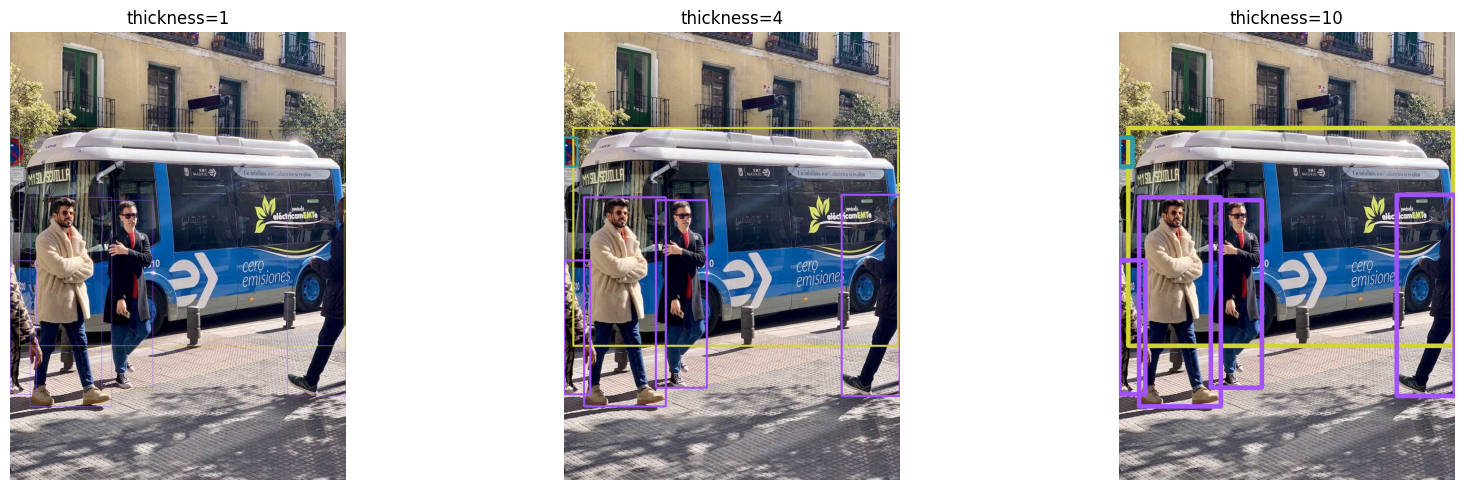

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, thickness in zip(axes, [1, 4, 10]):
    ann = sv.BoxAnnotator(thickness=thickness)
    scene = ann.annotate(scene=image.copy(), detections=detections)
    ax.imshow(cv2.cvtColor(scene, cv2.COLOR_BGR2RGB))
    ax.set_title(f"thickness={thickness}")
    ax.axis("off")
plt.tight_layout()
plt.show()
# 💭 Reflexión: ¿Qué grosor resulta más legible?
# Para imágenes de alta resolución generalmente se necesita más grosor.
# Para pantallas pequeñas, menos grosor evita que las cajas tapen el objeto.

### Tamaño del texto de las etiquetas

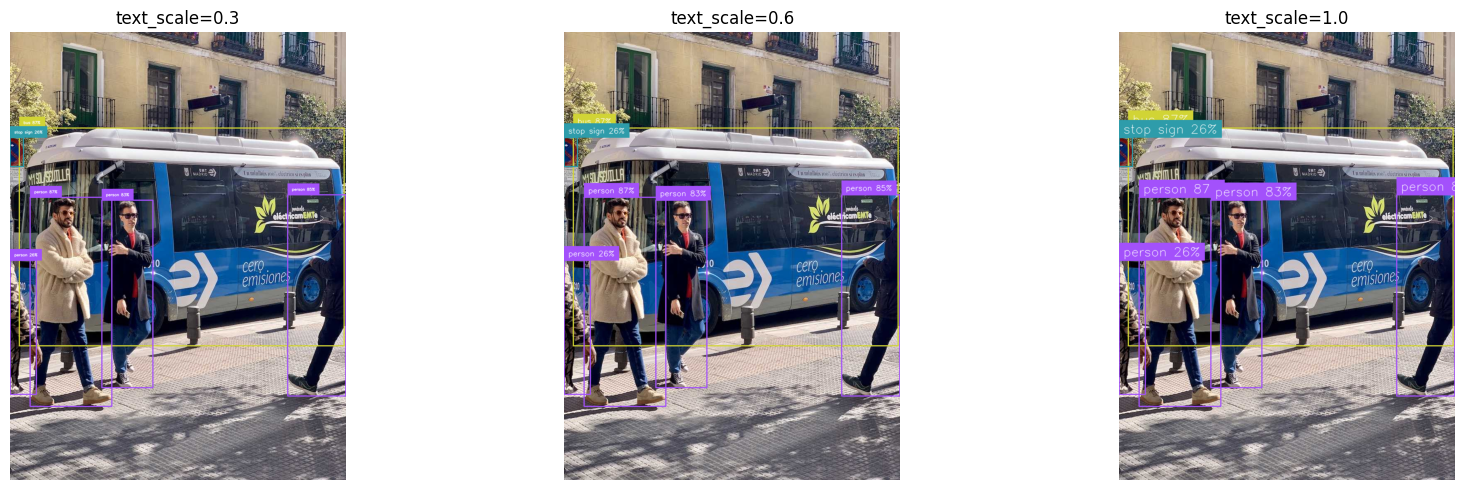

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, scale in zip(axes, [0.3, 0.6, 1.0]):
    box_ann   = sv.BoxAnnotator()
    label_ann = sv.LabelAnnotator(text_scale=scale)
    scene = box_ann.annotate(scene=image.copy(), detections=detections)
    scene = label_ann.annotate(scene=scene, detections=detections, labels=labels)
    ax.imshow(cv2.cvtColor(scene, cv2.COLOR_BGR2RGB))
    ax.set_title(f"text_scale={scale}")
    ax.axis("off")
plt.tight_layout()
plt.show()
# 💭 Reflexión: ¿text_scale=0.3 es legible en esta imagen?
# El tamaño adecuado depende de la resolución y del tamaño de los objetos detectados.

### El orden de las capas importa

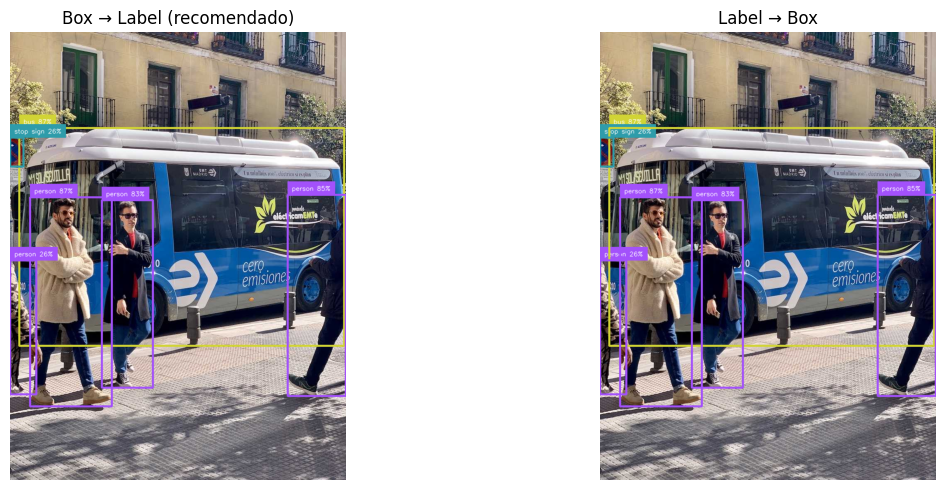

In [7]:
box_ann   = sv.BoxAnnotator(thickness=3)
label_ann = sv.LabelAnnotator()

# Orden A: Box primero, Label encima
orden_a = box_ann.annotate(scene=image.copy(), detections=detections)
orden_a = label_ann.annotate(scene=orden_a, detections=detections, labels=labels)

# Orden B: Label primero, Box encima
# La caja del Box tapa parte del texto de Label
orden_b = label_ann.annotate(scene=image.copy(), detections=detections, labels=labels)
orden_b = box_ann.annotate(scene=orden_b, detections=detections)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.imshow(cv2.cvtColor(orden_a, cv2.COLOR_BGR2RGB))
ax1.set_title("Box → Label (recomendado)")
ax1.axis("off")
ax2.imshow(cv2.cvtColor(orden_b, cv2.COLOR_BGR2RGB))
ax2.set_title("Label → Box")
ax2.axis("off")
plt.tight_layout()
plt.show()
# 💭 Reflexión: ¿Por qué "Box → Label" es más legible?
# Label dibuja el texto encima de lo que ya existe en la imagen.
# Si Box va después, su línea puede tapar parte del texto.

## Reto de extensión

**Tarea:** Crea tu combinación de annotators favorita usando al menos 3 annotators diferentes.

Explora la lista completa en: https://supervision.roboflow.com/latest/detection/annotators/

**Pista:** Prueba `sv.DotAnnotator`, `sv.TriangleAnnotator`, o `sv.EllipseAnnotator`.
Cada uno acepta los mismos parámetros base: `color=` y posiblemente `thickness=` o `radius=`.

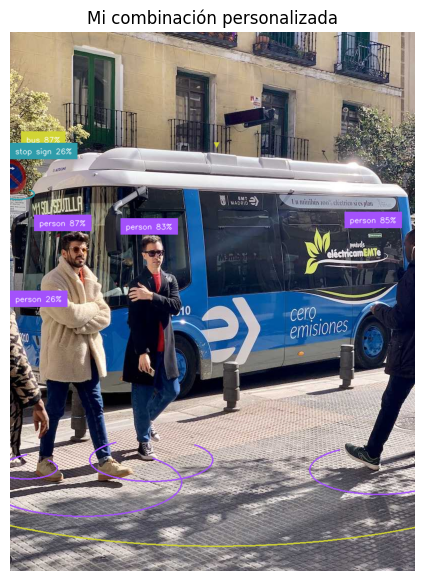

In [8]:
scene = image.copy()

scene = sv.EllipseAnnotator().annotate(
    scene=scene,
    detections=detections
)

scene = sv.TriangleAnnotator().annotate(
    scene=scene,
    detections=detections
)

scene = sv.LabelAnnotator().annotate(
    scene=scene,
    detections=detections,
    labels=labels
)

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(scene, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Mi combinación personalizada")
plt.show()

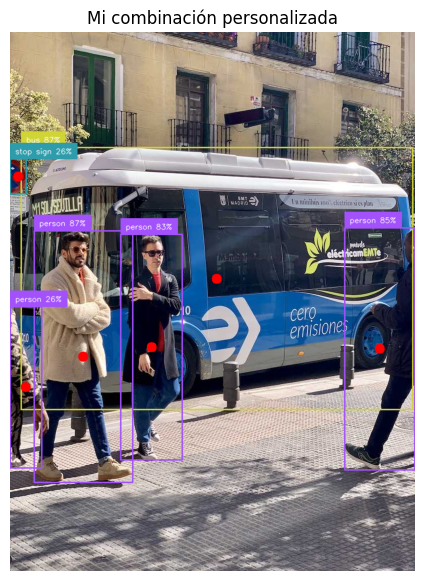

In [12]:
scene = image.copy()

scene = sv.BoxAnnotator().annotate(
    scene=scene,
    detections=detections
)

scene = sv.DotAnnotator(
    radius=10,
    color=sv.Color.RED
).annotate(
    scene=scene,
    detections=detections
)

scene = sv.LabelAnnotator().annotate(
    scene=scene,
    detections=detections,
    labels=labels
)

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(scene, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Mi combinación personalizada")
plt.show()